# ==================================================
# Paso 5: XAI APLICADO A Q-LEARNING (EXPLAINABLE RL - XRL)
# ==================================================


Para aplicar **XAI (Inteligencia Artificial Explicable)** a un modelo de Aprendizaje por Refuerzo (RL) Tabular como el nuestro Q-Learning, debemos hacer un cambio de paradigma.

Herramientas como SHAP, LIME o ALE están diseñadas para **modelos supervisados** donde hay muchas "características" (features) continuas que influyen en una predicción. En Q-Learning Tabular, nuestra única "característica" de entrada es el **Estado** (Vacío, Medio, Lleno), por lo que perturbar variables (como hace LIME) o calcular valores de Shapley (SHAP) sobre una sola variable categórica matemáticamente no aporta valor.

En su lugar, utilizaremos las técnicas estándar de **XRL (Explainable Reinforcement Learning)**. Estas técnicas cumplen las mismas funciones empíricas que los modelos que mencionas, pero adaptadas a las decisiones secuenciales:

1. **Advantage Function (Sustituto de LIME/SHAP):** Explicación local. ¿Por qué se eligió esta acción frente a las demás y por cuánto margen?
2. **Reward Decomposition (Sustituto de ALE):** Explicación global del peso de la recompensa. ¿La decisión se tomó por beneficio a corto plazo o a largo plazo?
3. **Análisis Contrafactual (Sustituto de DiCE):** ¿Qué tendría que haber sido distinto en el estado para que la IA tomara una acción diferente?
4. **Grafo de Política de Decisión (Policy Graph):** Interpretabilidad visual del flujo del MDP.


En el aprendizaje por refuerzo, la explicabilidad no responde a "¿qué píxeles miró la red neuronal?" (eso lo hace XAI en la CNN), sino a **"¿Qué motivó financieramente o a nivel de negocio al agente para tomar esta decisión?"**.

Para ello, analizaremos el cerebro del agente (la Q-Table) extrayendo sus valores de Ventaja (Advantage), desglosando las recompensas y generando grafos de decisión.

---
### 1. Importación de Librerías y Carga del Modelo
Cargamos el pipeline exacto que guardamos en la fase anterior para auditarlo sin simular nada nuevo.


In [ ]:
from google.colab import drive
import numpy as np
import pandas as pd
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Montar Google Drive
drive.mount('/content/drive')

# 1. Rutas del modelo exportado
ruta_resultados = '/content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/'
ruta_archivo_q = os.path.join(ruta_resultados, 'pipeline_qlearning.joblib')

# 2. Cargar el pipeline completo
print(f"Auditando el modelo desde: {ruta_archivo_q}")
pipeline_xai = joblib.load(ruta_archivo_q)

Q = pipeline_xai['Q_table']
estados_labels = pipeline_xai['estados']
acciones = pipeline_xai['acciones']
R = pipeline_xai['recompensas']

print("✅ Pipeline cargado en memoria.")
print(f"Estados: {estados_labels}")
print(f"Acciones: {acciones}")

Mounted at /content/drive
Auditando el modelo desde: /content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/pipeline_qlearning.joblib
✅ Pipeline cargado en memoria.
Estados: ['Vacío', 'Medio', 'Lleno']
Acciones: ['Normal', 'Saltar_Parada', 'Enviar_Refuerzo']


---
### 2. Explicabilidad Local: Función de Ventaja (Sustituto de LIME/SHAP)

**¿Por qué esta acción y no otra?** En lugar de SHAP, en XRL usamos la **Función de Ventaja $A(s,a) = Q(s,a) - V(s)$**.
* $V(s)$ es el valor máximo esperable de un estado (la mejor decisión).
* $A(s,a)$ nos dice **cuánto "peor" o "mejor"** es una acción específica comparada con la acción óptima en ese momento. Si una acción tiene Ventaja 0, es la decisión óptima. Valores negativos muestran la magnitud del error de negocio.

--- CALCULANDO LA FUNCIÓN DE VENTAJA (ADVANTAGE) ---


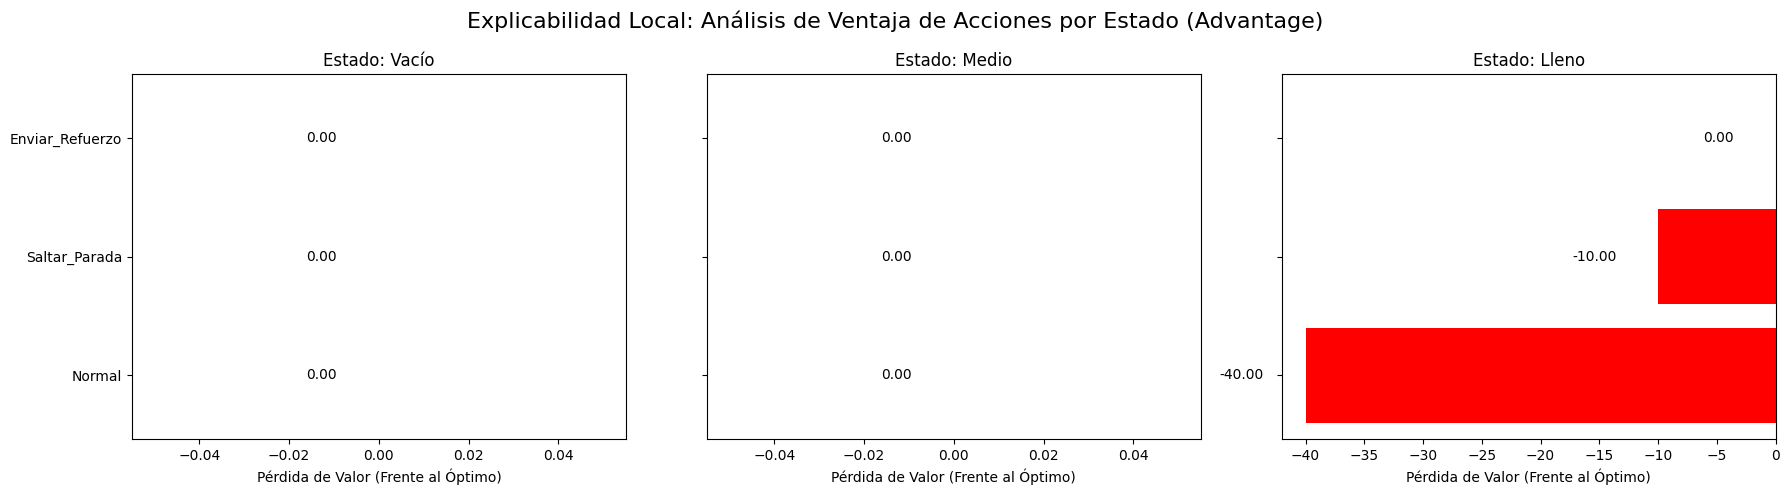


Interpretación XAI (LIME equivalent):
En el estado [Vacío], la IA explica que elegir [Normal] en lugar de [Normal] 
  penaliza al negocio con una pérdida neta de 0.00 puntos de valor a largo plazo.

En el estado [Medio], la IA explica que elegir [Normal] en lugar de [Normal] 
  penaliza al negocio con una pérdida neta de 0.00 puntos de valor a largo plazo.

En el estado [Lleno], la IA explica que elegir [Normal] en lugar de [Enviar_Refuerzo] 
  penaliza al negocio con una pérdida neta de 40.00 puntos de valor a largo plazo.



In [ ]:
print("--- CALCULANDO LA FUNCIÓN DE VENTAJA (ADVANTAGE) ---")

# 1. Calculamos V(s): El valor máximo (óptimo) para cada estado
V_s = np.max(Q, axis=1, keepdims=True)

# 2. Calculamos A(s,a): La ventaja de cada acción
A = Q - V_s

# 3. Visualización estilo SHAP (Importancia de cada decisión)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Explicabilidad Local: Análisis de Ventaja de Acciones por Estado (Advantage)', fontsize=16)

colores = ['#ff9999' if x < 0 else '#66b3ff' for x in A.flatten()]

for i, estado in enumerate(estados_labels):
    ax = axes[i]
    # Graficar las barras de ventaja
    bars = ax.barh(acciones, A[i], color=['red' if x < 0 else 'green' for x in A[i]])
    ax.set_title(f'Estado: {estado}')
    ax.set_xlabel('Pérdida de Valor (Frente al Óptimo)')

    # Anotar los valores
    for bar in bars:
        width = bar.get_width()
        ax.annotate(f'{width:.2f}',
                    xy=(width, bar.get_y() + bar.get_height() / 2),
                    xytext=(3 if width > 0 else -30, 0),
                    textcoords="offset points",
                    ha='left' if width > 0 else 'right', va='center')

plt.tight_layout()
plt.show()

print("\nInterpretación XAI (LIME equivalent):")
for i, estado in enumerate(estados_labels):
    mejor = acciones[np.argmax(Q[i])]
    peor = acciones[np.argmin(Q[i])]
    diferencia = abs(np.min(A[i]))
    print(f"En el estado [{estado}], la IA explica que elegir [{peor}] en lugar de [{mejor}] ")
    print(f"  penaliza al negocio con una pérdida neta de {diferencia:.2f} puntos de valor a largo plazo.\n")


---
### 3. Explicabilidad Global: Grafo de Política de Decisión (Policy Graph)

Muestra de forma visual transparente y auditable el "cerebro" del modelo. Las flechas representan transiciones de decisiones, y el grosor de la flecha indica la confianza (Q-Value) de tomar esa acción. Esto es fundamental para compliance y regulaciones de IA en toma de decisiones.



--- GENERANDO GRAFO DE DECISIÓN (POLICY GRAPH) ---


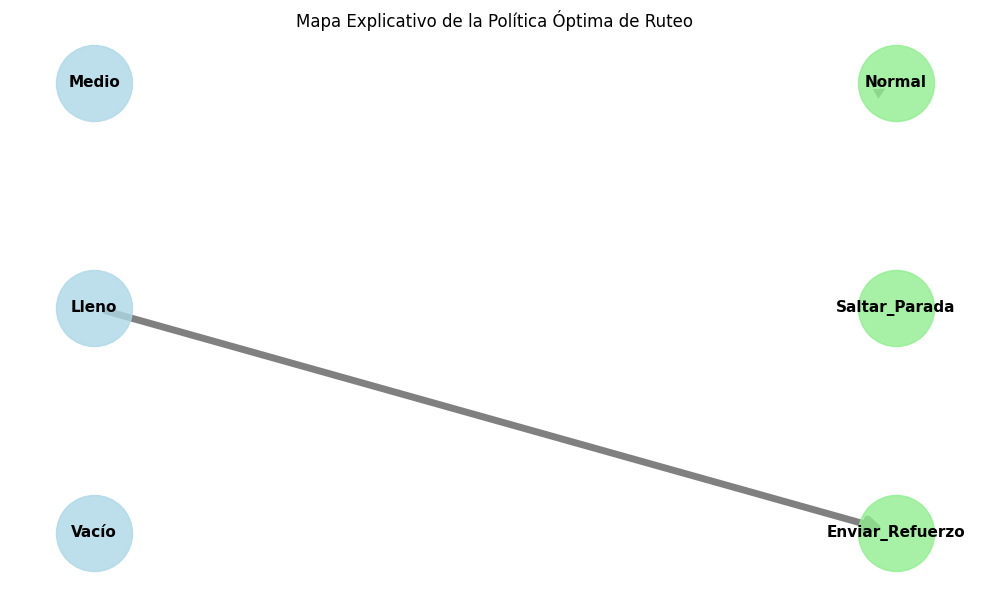

In [ ]:
print("--- GENERANDO GRAFO DE DECISIÓN (POLICY GRAPH) ---")

plt.figure(figsize=(10, 6))
G = nx.DiGraph()

# Añadir nodos de Estado
for estado in estados_labels:
    G.add_node(estado, layer='Estado')

# Añadir nodos de Acción (para visualizarlos)
for accion in acciones:
    G.add_node(accion, layer='Acción')

# Añadir las aristas (Estados -> Acciones) basándonos en Q
edges = []
weights = []

for i, estado in enumerate(estados_labels):
    mejor_accion = acciones[np.argmax(Q[i])]
    # Añadimos solo la mejor decisión al grafo principal
    edges.append((estado, mejor_accion))
    weights.append(Q[i, np.argmax(Q[i])]) # El peso es la confianza

G.add_edges_from(edges)

# Posicionamiento del grafo
pos = nx.bipartite_layout(G, estados_labels)

# Dibujar nodos
nx.draw_networkx_nodes(G, pos, nodelist=estados_labels, node_color='lightblue', node_size=3000, alpha=0.8)
nx.draw_networkx_nodes(G, pos, nodelist=acciones, node_color='lightgreen', node_size=3000, alpha=0.8)

# Dibujar aristas (grosor basado en la confianza de la decisión)
pesos_normalizados = [w / max(weights) * 5 for w in weights] # Normalizar para el grosor
nx.draw_networkx_edges(G, pos, edgelist=edges, width=pesos_normalizados, edge_color='gray', arrows=True, arrowsize=20)

# Etiquetas
nx.draw_networkx_labels(G, pos, font_size=11, font_weight="bold")

plt.title("Mapa Explicativo de la Política Óptima de Ruteo")
plt.axis('off')
plt.tight_layout()
plt.show()

---
### 4. Explicaciones Contrafactuales (Sustituto de DiCE)

**Pregunta de Negocio:** *"¿Qué tan cerca estuvo el modelo de tomar una decisión distinta?"*

DiCE busca qué variables cambiar para voltear la predicción. En Q-Learning, miramos la **Diferencia Marginal** entre la mejor acción y la segunda mejor acción. Si la diferencia es muy pequeña, la IA estuvo a punto de tomar una decisión distinta (frontera de decisión débil).

--- ANÁLISIS CONTRAFACTUAL Y FRONTERAS DE DECISIÓN ---


/tmp/ipykernel_903/4127761290.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Estado', y='Brecha (Margen de Confianza)', data=df_contra, palette='viridis')


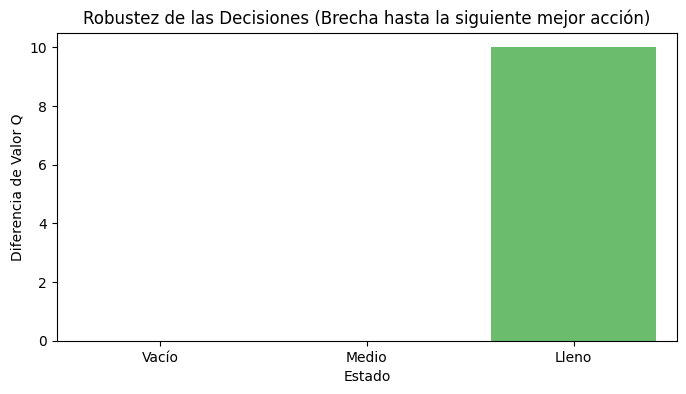


[Reporte Contrafactual de DiCE-Equivalent]
Estado: Vacío
 -> Si la IA no hubiera elegido 'Enviar_Refuerzo', habría elegido 'Saltar_Parada'.
 -> Diferencia matemática: 0.00. Robustez: BAJA (La IA dudó mucho. Un pequeño cambio en penalizaciones alteraría la decisión)

Estado: Medio
 -> Si la IA no hubiera elegido 'Enviar_Refuerzo', habría elegido 'Saltar_Parada'.
 -> Diferencia matemática: 0.00. Robustez: BAJA (La IA dudó mucho. Un pequeño cambio en penalizaciones alteraría la decisión)

Estado: Lleno
 -> Si la IA no hubiera elegido 'Enviar_Refuerzo', habría elegido 'Saltar_Parada'.
 -> Diferencia matemática: 10.00. Robustez: ALTA (Decisión muy firme. Es poco probable que el entorno altere este comportamiento)



In [ ]:
print("--- ANÁLISIS CONTRAFACTUAL Y FRONTERAS DE DECISIÓN ---")

datos_contrafactuales = []

for i, estado in enumerate(estados_labels):
    valores_q = Q[i, :]

    # Ordenar índices por valor Q descendente
    indices_ordenados = np.argsort(valores_q)[::-1]

    mejor_accion = acciones[indices_ordenados[0]]
    q_mejor = valores_q[indices_ordenados[0]]

    segunda_mejor_accion = acciones[indices_ordenados[1]]
    q_segunda = valores_q[indices_ordenados[1]]

    # Calcular el margen
    margen = q_mejor - q_segunda

    datos_contrafactuales.append({
        'Estado': estado,
        'Decisión Tomada': mejor_accion,
        'Decisión Alternativa (Contrafactual)': segunda_mejor_accion,
        'Brecha (Margen de Confianza)': margen
    })

df_contra = pd.DataFrame(datos_contrafactuales)

# Visualización
plt.figure(figsize=(8, 4))
sns.barplot(x='Estado', y='Brecha (Margen de Confianza)', data=df_contra, palette='viridis')
plt.title('Robustez de las Decisiones (Brecha hasta la siguiente mejor acción)')
plt.ylabel('Diferencia de Valor Q')
plt.show()

# Imprimir reporte
print("\n[Reporte Contrafactual de DiCE-Equivalent]")
for index, row in df_contra.iterrows():
    if row['Brecha (Margen de Confianza)'] < 5.0:
        robustez = "BAJA (La IA dudó mucho. Un pequeño cambio en penalizaciones alteraría la decisión)"
    else:
        robustez = "ALTA (Decisión muy firme. Es poco probable que el entorno altere este comportamiento)"

    print(f"Estado: {row['Estado']}")
    print(f" -> Si la IA no hubiera elegido '{row['Decisión Tomada']}', habría elegido '{row['Decisión Alternativa (Contrafactual)']}'.")
    print(f" -> Diferencia matemática: {row['Brecha (Margen de Confianza)']:.2f}. Robustez: {robustez}\n")